In [ ]:
pip install pandas_datareader

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas_datareader.data as web
from sklearn.linear_model import LinearRegression
import seaborn as sns

<ipython-input-2-17b835005405>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  eurusd_monthly = eurusd.resample('M').mean()
<ipython-input-2-17b835005405>:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fed_rate_monthly = fedfunds.resample('M').mean()
<ipython-input-2-17b835005405>:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ecb_rate_monthly = ecb_rate.resample('M').mean()
<ipython-input-2-17b835005405>:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tbill1y_monthly = tbill1y.resample('M').mean()
<ipython-input-2-17b835005405>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  euro_govbond_monthly = euro_govbond.resample('M').mean()
<ipython-input-2-17b835005405>:27: FutureWarning: 'M' is deprecated and w

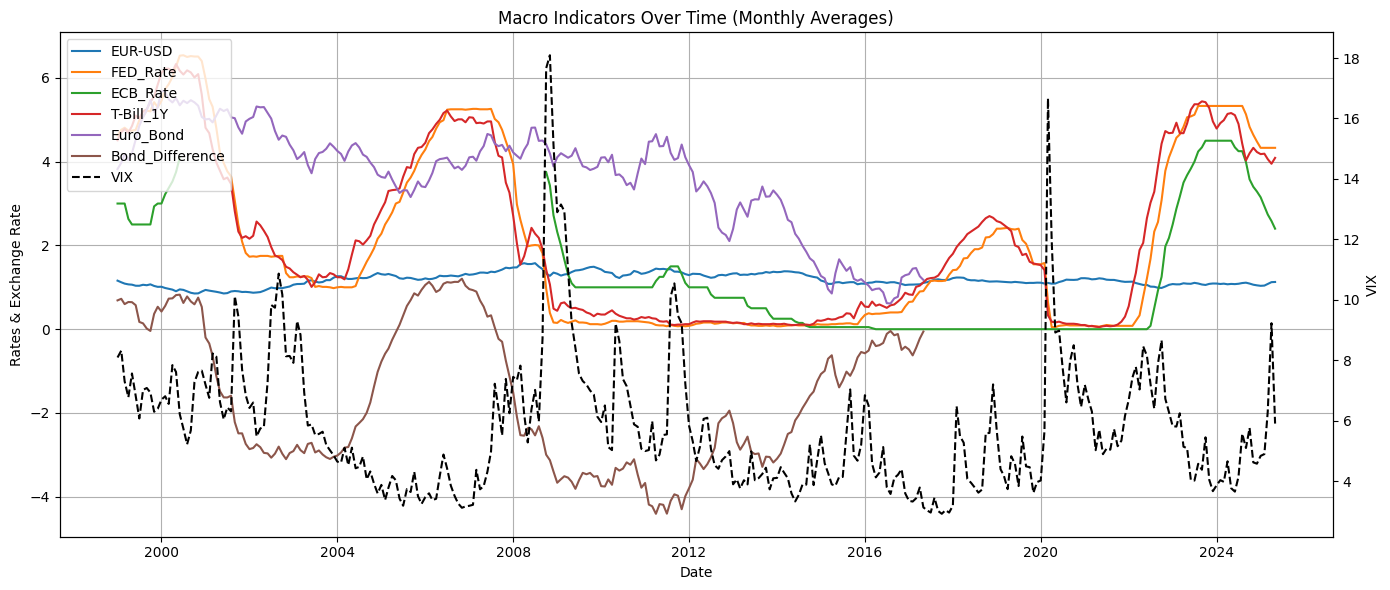

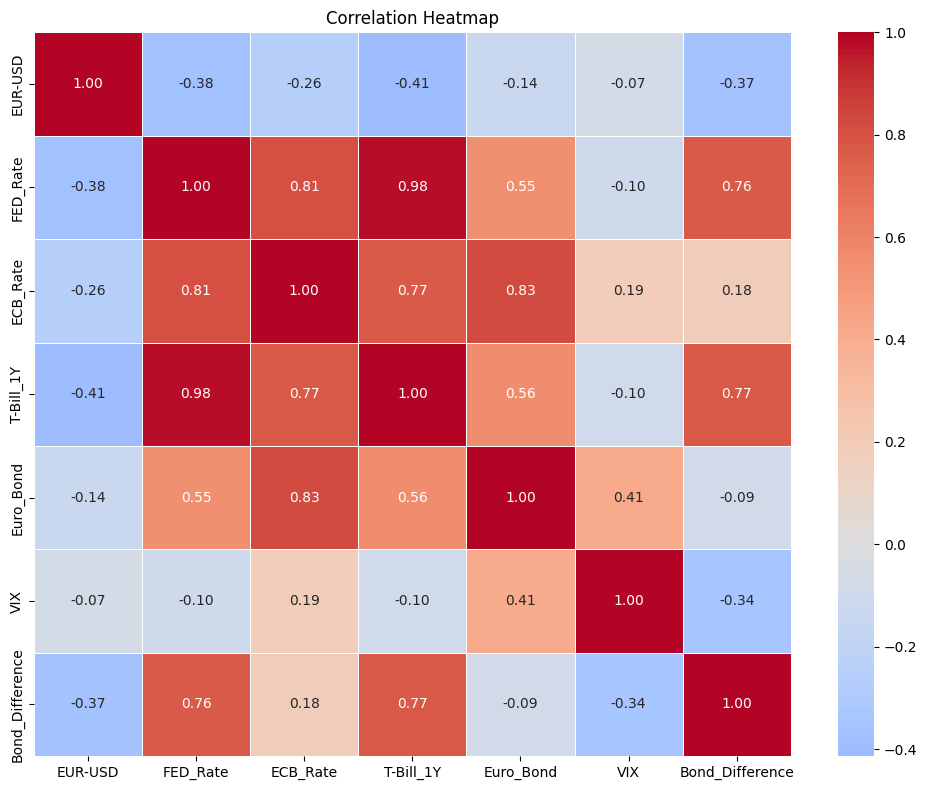

In [2]:
#For ease and data visualization
start = datetime(1999, 1, 1)
end = datetime(2025, 5, 31)

eurusd = web.DataReader("DEXUSEU", "fred", start, end)
fedfunds = web.DataReader("FEDFUNDS", "fred", start, end)
ecb_rate = web.DataReader("ECBMRRFR", "fred", start, end)
tbill1y = web.DataReader("GS1", "fred", start, end)
euro_govbond = web.DataReader("INTGSBEZM193N", "fred", start, end)

eurusd_monthly = eurusd.resample('M').mean()
fed_rate_monthly = fedfunds.resample('M').mean()
ecb_rate_monthly = ecb_rate.resample('M').mean()
tbill1y_monthly = tbill1y.resample('M').mean()
euro_govbond_monthly = euro_govbond.resample('M').mean()

eurusd_monthly.index        = eurusd_monthly.index.to_period('M').to_timestamp()
fed_rate_monthly.index      = fed_rate_monthly.index.to_period('M').to_timestamp()
ecb_rate_monthly.index      = ecb_rate_monthly.index.to_period('M').to_timestamp()
tbill1y_monthly.index       = tbill1y_monthly.index.to_period('M').to_timestamp()
euro_govbond_monthly.index  = euro_govbond_monthly.index.to_period('M').to_timestamp()


start = "1999-01-01"
end = "2025-05-31"
vix = web.DataReader("VIXCLS", "fred", start, end)
vix_monthly = vix.resample('M').mean()

vix_monthly.index = vix_monthly.index.to_period('M').to_timestamp()
vix_monthly['vix'] = vix_monthly['VIXCLS'] / (12 ** 0.5)

vix_monthly.drop(['VIXCLS'],axis =1,inplace=True)

df = pd.concat([
    eurusd_monthly.rename(columns={"DEXUSEU": "EUR-USD"}),
    fed_rate_monthly.rename(columns={"FEDFUNDS": "FED_Rate"}),
    ecb_rate_monthly.rename(columns={"ECBMRRFR": "ECB_Rate"}),
    tbill1y_monthly.rename(columns={"GS1": "T-Bill_1Y"}),
    euro_govbond_monthly.rename(columns={"INTGSBEZM193N": "Euro_Bond"}),
    vix_monthly.rename(columns = {"vix" : "VIX"})
], axis=1)

df["Bond_Difference"] = df["T-Bill_1Y"] - df["Euro_Bond"]

plt.figure(figsize=(14, 6))

# Left y-axis is all features except VIX
ax1 = plt.gca()
for col in ["EUR-USD", "FED_Rate", "ECB_Rate", "T-Bill_1Y", "Euro_Bond", "Bond_Difference"]:
    ax1.plot(df.index, df[col], label=col)
ax1.set_ylabel("Rates & Exchange Rate")
ax1.set_xlabel("Date")
ax1.tick_params(axis='y')
ax1.grid(True)

#Right y-axis is only for VIX
ax2 = ax1.twinx()
ax2.plot(df.index, df["VIX"], label="VIX", color="black", linestyle="--")
ax2.set_ylabel("VIX")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.title("Macro Indicators Over Time (Monthly Averages)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0, linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

<ipython-input-3-806aba5cbcd9>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  eurusd_monthly = eurusd.resample('M').mean()
<ipython-input-3-806aba5cbcd9>:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fed_rate_monthly = fedfunds.resample('M').mean()
<ipython-input-3-806aba5cbcd9>:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ecb_rate_monthly = ecb_rate.resample('M').mean()
<ipython-input-3-806aba5cbcd9>:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tbill1y_monthly = tbill1y.resample('M').mean()
<ipython-input-3-806aba5cbcd9>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  euro_govbond_monthly = euro_govbond.resample('M').mean()


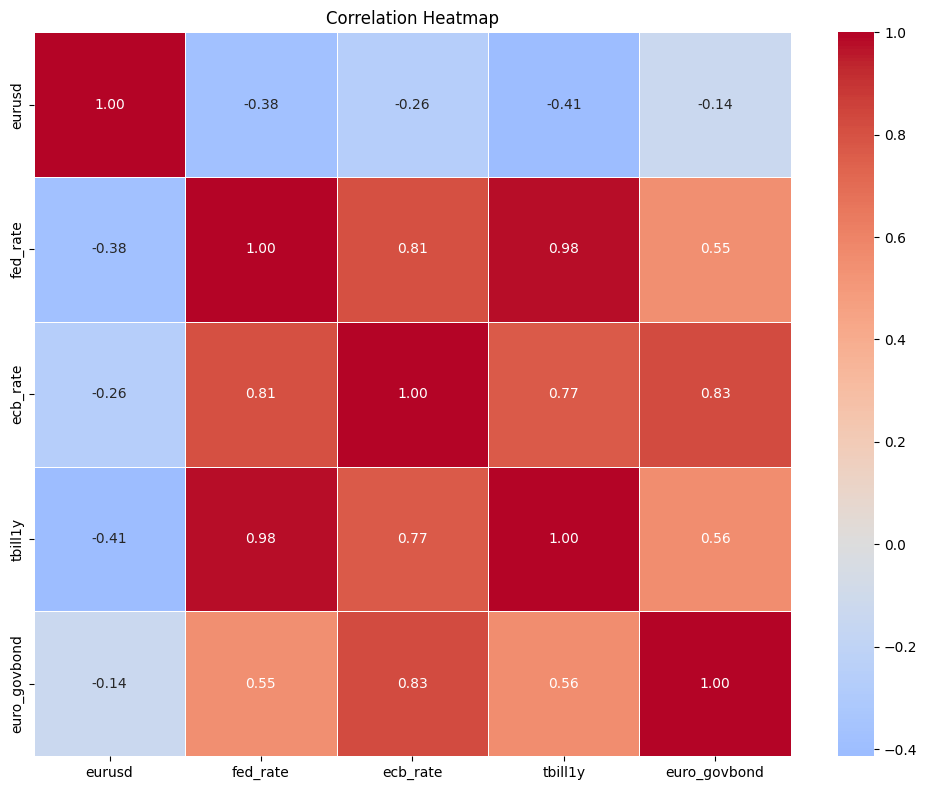

In [3]:
start = datetime(1999, 1, 1)
end = datetime(2025, 5, 31)

eurusd = web.DataReader("DEXUSEU", "fred", start, end)
fedfunds = web.DataReader("FEDFUNDS", "fred", start, end)
ecb_rate = web.DataReader("ECBMRRFR", "fred", start, end)
tbill1y = web.DataReader("GS1", "fred", start, end)
euro_govbond = web.DataReader("INTGSBEZM193N", "fred", start, end)


eurusd_monthly = eurusd.resample('M').mean()
fed_rate_monthly = fedfunds.resample('M').mean()
ecb_rate_monthly = ecb_rate.resample('M').mean()
tbill1y_monthly = tbill1y.resample('M').mean()
euro_govbond_monthly = euro_govbond.resample('M').mean()

eurusd_monthly.index        = eurusd_monthly.index.to_period('M').to_timestamp()
fed_rate_monthly.index      = fed_rate_monthly.index.to_period('M').to_timestamp()
ecb_rate_monthly.index      = ecb_rate_monthly.index.to_period('M').to_timestamp()
tbill1y_monthly.index       = tbill1y_monthly.index.to_period('M').to_timestamp()
euro_govbond_monthly.index  = euro_govbond_monthly.index.to_period('M').to_timestamp()

data = pd.concat([
    eurusd_monthly.rename(columns={"DEXUSEU": "eurusd"}),
    fed_rate_monthly.rename(columns={"FEDFUNDS": "fed_rate"}),
    ecb_rate_monthly.rename(columns={"ECBMRRFR": "ecb_rate"}),
    tbill1y_monthly.rename(columns={"GS1": "tbill1y"}),
    euro_govbond_monthly.rename(columns={"INTGSBEZM193N": "euro_govbond"})
], axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", center=0, linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### LINEAR REGRESSION MODELS

Coefficients:
fed_rate: 0.10618613922727255
ecb_rate: 0.0075434838378269226
tbill1y: -0.15627755804172927
euro_govbond: 0.002392094693352498
bond_diff: -0.02515178186200811
Mean Squared Error: 0.003323124721564093
R^2 Score: -0.016349565324628168


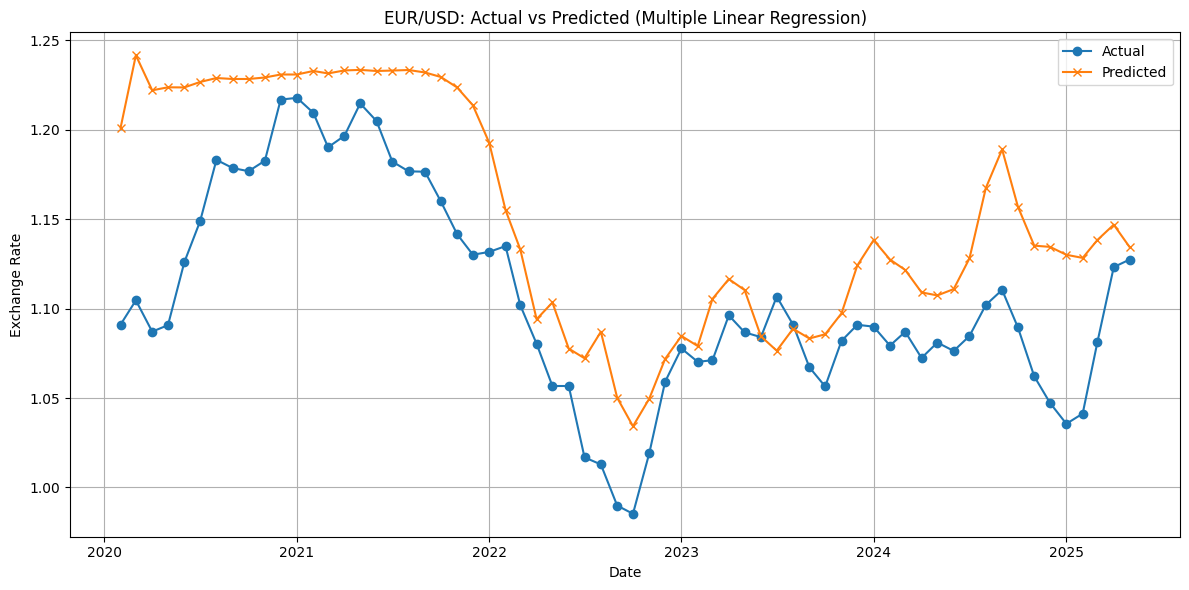

In [4]:
data["bond_diff"] = data["tbill1y"] - data["euro_govbond"]

data1 = data.ffill()
X = data1[["fed_rate", "ecb_rate", "tbill1y", "euro_govbond","bond_diff"]]
y = data1["eurusd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", marker='o')
plt.plot(y_test.index, y_pred, label="Predicted", marker='x')
plt.title("EUR/USD: Actual vs Predicted (Multiple Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


It is not so bad a start however, after literature review, we realized that gdp growth as percentage also could be used as an explanatory indicator. Since those data are quarterly, we changed our timestamp to quarter.

<ipython-input-5-df57d4709c35>:7: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  us_gdp.index = us_gdp.index.to_period('Q').to_timestamp('S')
<ipython-input-5-df57d4709c35>:8: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  euro_gdp.index = euro_gdp.index.to_period('Q').to_timestamp('S')
<ipython-input-5-df57d4709c35>:13: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  us_gdp_growth.index = us_gdp_growth.index.to_period('Q').to_timestamp('S')
<ipython-input-5-df57d4709c35>:14: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  euro_gdp_growth.index = euro_gdp_growth.index.to_period('Q').to_timestamp('S')
<ipython-input-5-df57d4709c35>:16: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  data_quarterly = data.resample('Q').mean()
<ip

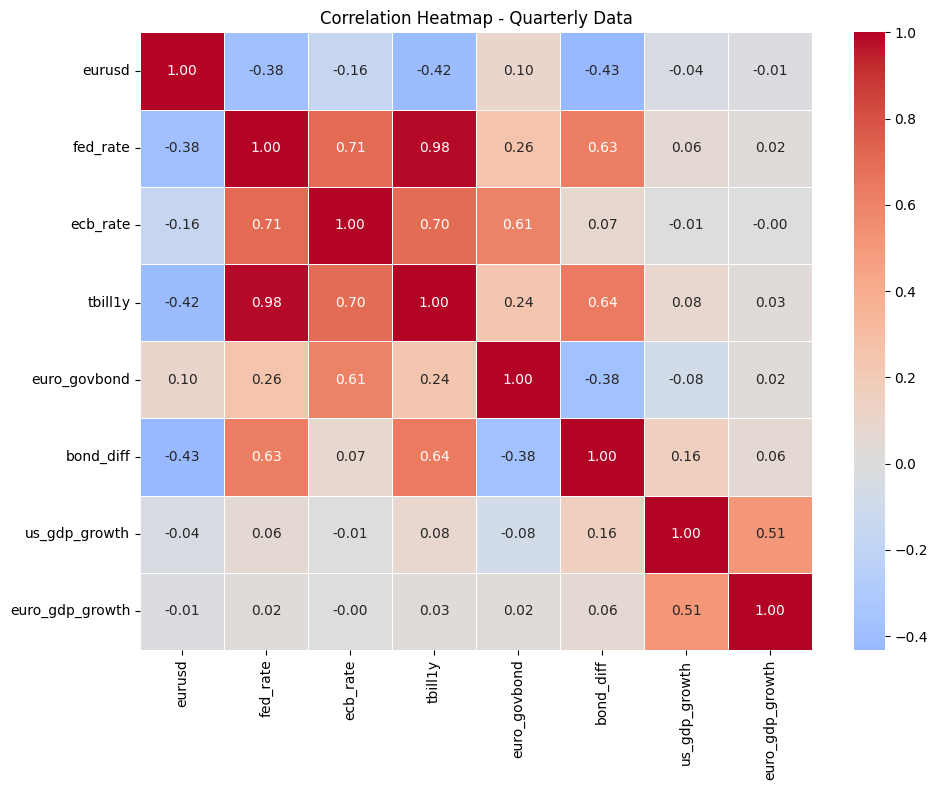

In [5]:
start = datetime(1999, 1, 1)
end = datetime(2025, 5, 31)

us_gdp = web.DataReader("GDP", "fred",  start= "1985-01-01", end= end)                # ABD GDP (Çeyreklik)
euro_gdp = web.DataReader("CLVMNACNSAB1GQEA", "fred",  start= "1985-01-01", end= end) # Euro Bölgesi GDP (Çeyreklik)

us_gdp.index = us_gdp.index.to_period('Q').to_timestamp('S')
euro_gdp.index = euro_gdp.index.to_period('Q').to_timestamp('S')

us_gdp_growth = us_gdp.pct_change().dropna() * 100
euro_gdp_growth = euro_gdp.pct_change().dropna() * 100

us_gdp_growth.index = us_gdp_growth.index.to_period('Q').to_timestamp('S')
euro_gdp_growth.index = euro_gdp_growth.index.to_period('Q').to_timestamp('S')

data_quarterly = data.resample('Q').mean()
data_quarterly.index = data_quarterly.index.to_period('Q').to_timestamp('S')

data_quarterly = data_quarterly.merge(us_gdp_growth.rename(columns={"GDP": "us_gdp_growth"}),
                                      left_index=True, right_index=True, how='left')

data_quarterly = data_quarterly.merge(euro_gdp_growth.rename(columns={"CLVMNACNSAB1GQEA": "euro_gdp_growth"}),
                                      left_index=True, right_index=True, how='left')

data_quarterly = data_quarterly.ffill()

plt.figure(figsize=(10, 8))
sns.heatmap(data_quarterly.corr(), annot=True, cmap="coolwarm", center=0, linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap - Quarterly Data")
plt.tight_layout()
plt.show()


Coefficients:
fed_rate: 0.12342125582007787
ecb_rate: 0.010748088397874708
tbill1y: -0.17436329955432447
euro_govbond: -0.0008101304544931263
bond_diff: -0.026358705526667664
us_gdp_growth: 0.006126229182832992
euro_gdp_growth: -0.004760504900930264
Mean Squared Error: 0.003996272679424769
R^2 Score: -0.335393555703162


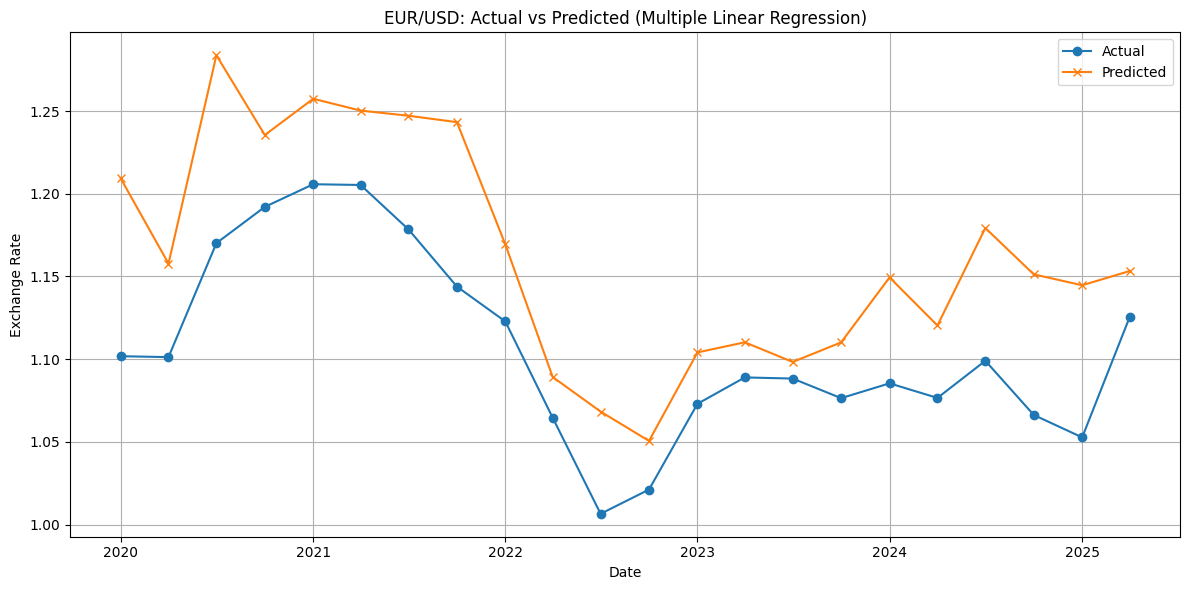

In [6]:
features = ["fed_rate", "ecb_rate", "tbill1y", "euro_govbond", "bond_diff","us_gdp_growth", "euro_gdp_growth"]
data_quarterly = data_quarterly.ffill()

X = data_quarterly[features]
y = data_quarterly["eurusd"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", marker='o')
plt.plot(y_test.index, y_pred, label="Predicted", marker='x')
plt.title("EUR/USD: Actual vs Predicted (Multiple Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The improvement is still not significant as expected to be a base model. Therefore, a new feature VIX added to show volatility in the model.

In [7]:
start = "1999-01-01"
end = "2025-05-31"

vix = web.DataReader("VIXCLS", "fred", start, end)
vix_quarterly = vix.resample('Q').mean()
vix_quarterly.index = vix_quarterly.index.to_period('Q').to_timestamp()
vix_quarterly['vix_quarterly'] = vix_quarterly['VIXCLS'] / (4 ** 0.5)
vix_quarterly = vix_quarterly[['vix_quarterly']]
data_quarterly = data_quarterly.merge(vix_quarterly, left_index=True, right_index=True, how='left')

data_quarterly = data_quarterly.ffill()

data_quarterly

<ipython-input-7-388a4790b785>:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  vix_quarterly = vix.resample('Q').mean()


,eurusd,fed_rate,ecb_rate,tbill1y,euro_govbond,bond_diff,us_gdp_growth,euro_gdp_growth,vix_quarterly
DATE,,,,,,,,,
1999-01-01,1.122654,4.733333,3.000000,4.663333,3.992400,0.670933,1.266313,-3.704015,13.626393
1999-04-01,1.056924,4.746667,2.544444,4.880000,4.257433,0.622567,1.216871,2.860106,12.197778
1999-07-01,1.049100,5.093333,2.500000,5.160000,5.050700,0.109300,1.683944,0.158662,11.660312
1999-10-01,1.038122,5.306667,2.811111,5.606667,5.320067,0.286600,2.204514,4.863480,11.329141
2000-01-01,0.986936,5.676667,3.198369,6.186667,5.617567,0.569100,1.030386,-2.977104,11.575159
...,...,...,...,...,...,...,...,...,...
2024-04-01,1.076577,5.330000,4.447222,5.136667,1.220250,-0.140250,1.371730,1.824459,6.990154
2024-07-01,1.099034,5.263333,4.163333,4.453333,1.220250,-0.140250,1.234461,0.397646,8.533333
2024-10-01,1.066272,4.650000,3.421505,4.253333,1.220250,-0.140250,1.187918,2.323509,8.681615


Coefficients:
fed_rate: 0.10322749539206376
ecb_rate: 0.009579382945788958
tbill1y: -0.10725389091539182
euro_govbond: -0.00549495511246894
bond_diff: -0.07606267232839742
us_gdp_growth: -0.0280817594450306
euro_gdp_growth: -0.0023171405610517386
vix_quarterly: -0.05889704372261469
Mean Squared Error: 0.02078423369491632
R^2 Score: -5.945254731820477


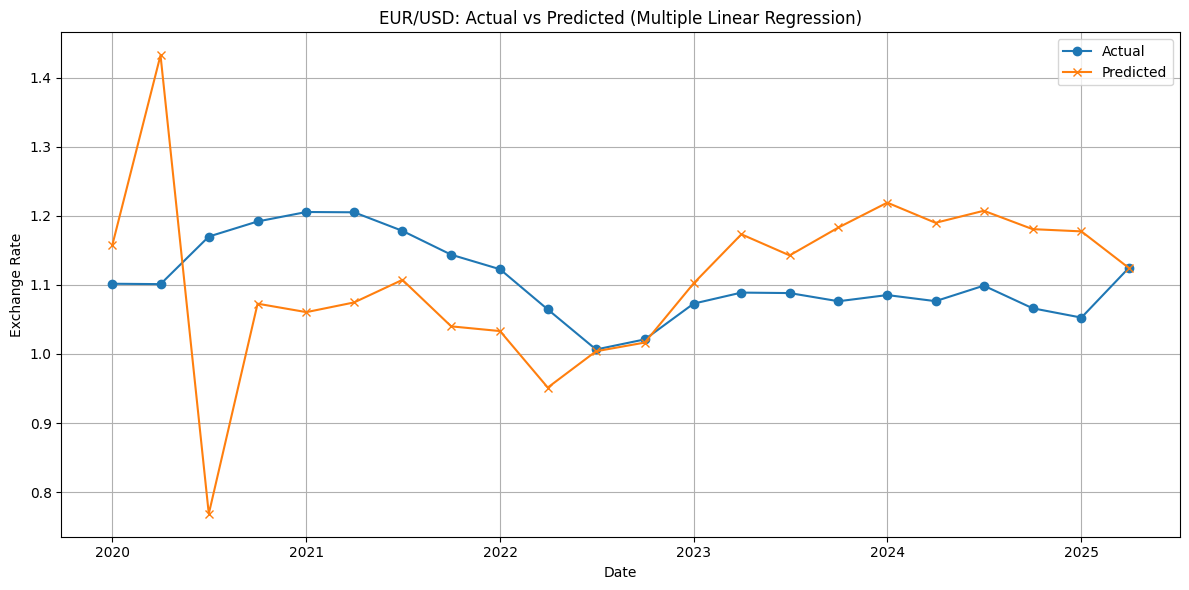

In [8]:
features = ["fed_rate", "ecb_rate", "tbill1y", "euro_govbond", "bond_diff","us_gdp_growth", "euro_gdp_growth","vix_quarterly"]

X = data_quarterly[features]
y = data_quarterly["eurusd"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", marker='o')
plt.plot(y_test.index, y_pred, label="Predicted", marker='x')
plt.title("EUR/USD: Actual vs Predicted (Multiple Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The model has become worse than before. One of the reasons might be combining data quarterly which make our data points less. Therefore, we returned back to monhtly data which means that we will first get VIX monthly and then create our new feature set.

<ipython-input-9-b594c8aec977>:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vix_monthly = vix.resample('M').mean()


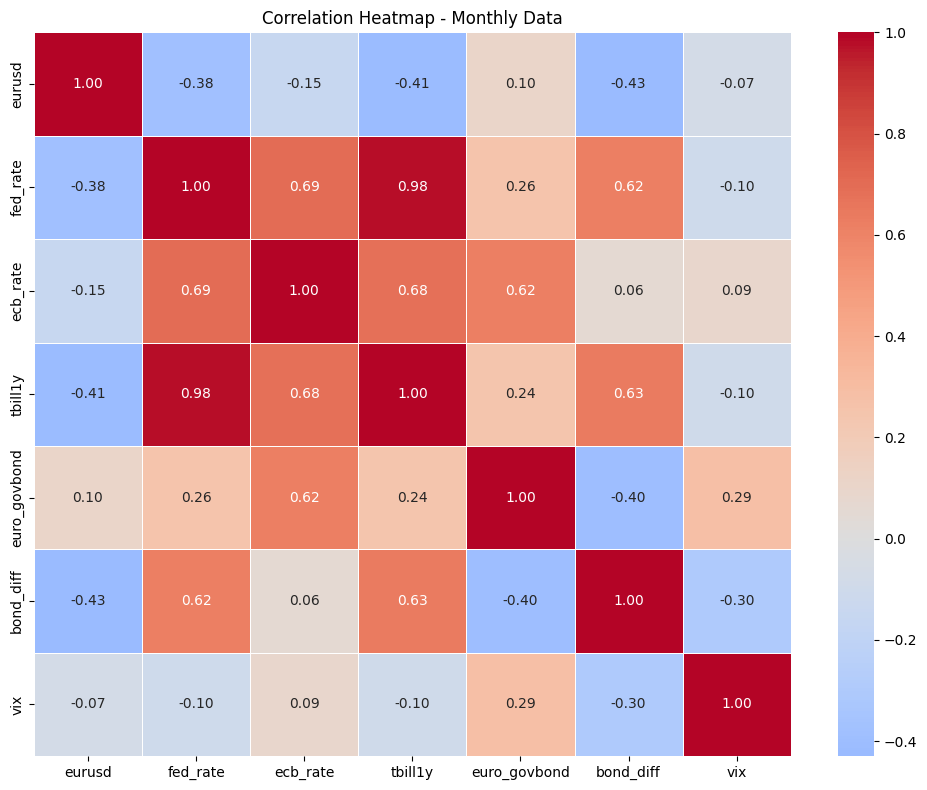

In [9]:
# VIX Chicago Board Options Exchange Volatility Index
start = "1999-01-01"
end = "2025-05-31"
vix = web.DataReader("VIXCLS", "fred", start, end)
vix_monthly = vix.resample('M').mean()

vix_monthly.index = vix_monthly.index.to_period('M').to_timestamp()
vix_monthly['vix'] = vix_monthly['VIXCLS'] / (12 ** 0.5)
vix_monthly.drop(['VIXCLS'], axis =1, inplace =True)
data = data.merge(vix_monthly[['vix']], left_index=True, right_index=True, how='left')

data2 = data.ffill()

plt.figure(figsize=(10, 8))
sns.heatmap(data2.corr(), annot=True, cmap="coolwarm", center=0, linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap - Monthly Data")
plt.tight_layout()
plt.show()


Coefficients:
fed_rate: 0.11699943088926071
ecb_rate: 0.006312030643021743
tbill1y: -0.13425743563235432
euro_govbond: -0.005641609512216039
bond_diff: -0.06475275007383319
vix: -0.03600727230654526
Mean Squared Error: 0.0037487996112652994
R^2 Score: -0.1465386269358342


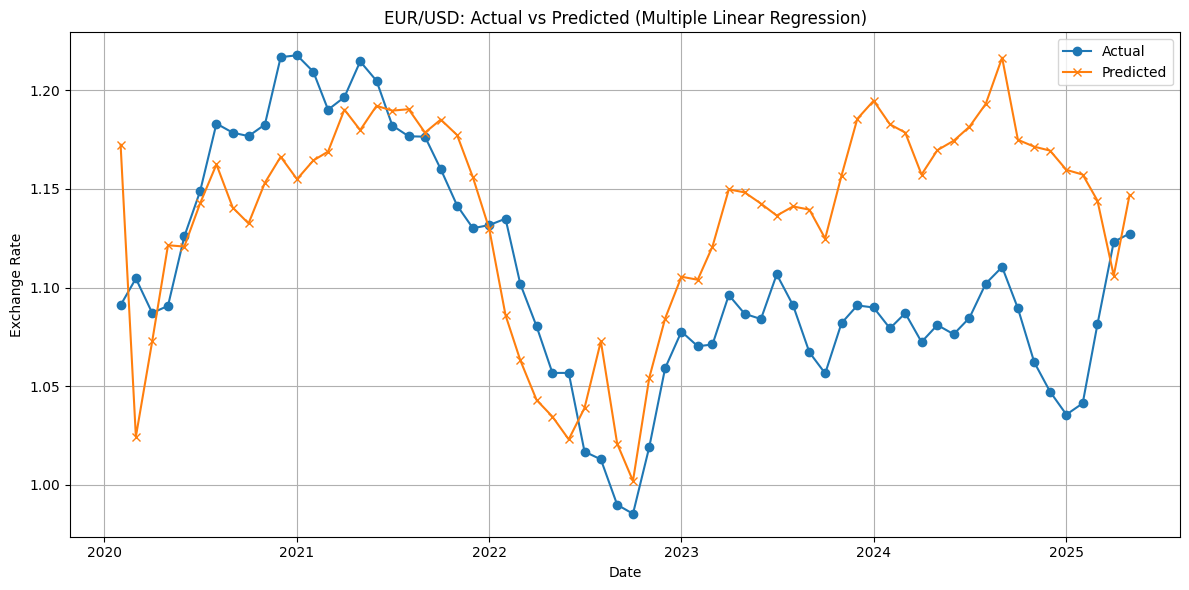

In [10]:
features = ["fed_rate", "ecb_rate", "tbill1y", "euro_govbond", "bond_diff", "vix"]

X = data2[features]
y = data2["eurusd"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", marker='o')
plt.plot(y_test.index, y_pred, label="Predicted", marker='x')
plt.title("EUR/USD: Actual vs Predicted (Multiple Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Coefficients:
fed_rate: 0.1158559639871223
ecb_rate: 0.005420279870721079
bond_diff: -0.05831267565372104
tbill1y: -0.13984913439404256
vix: -0.035939593192508
Mean Squared Error: 0.002816406574463872
R^2 Score: 0.13862589051833374


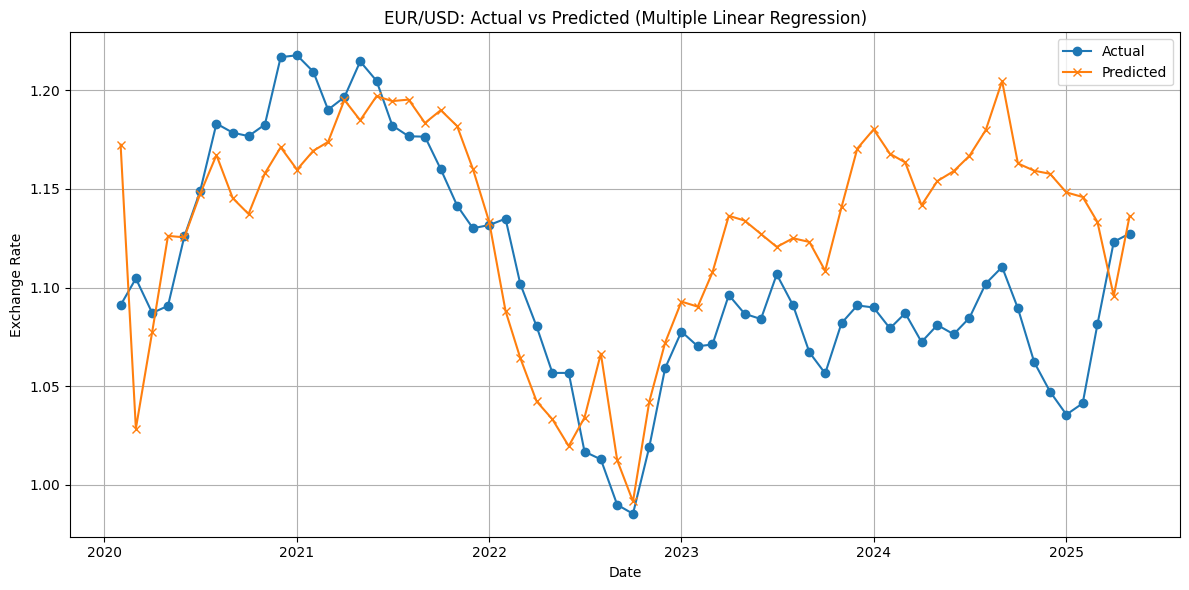

In [11]:
# LAST TRIAL - THE BEST RESULT SO FAR
features = ["fed_rate", "ecb_rate", "bond_diff","tbill1y","vix"]

X = data2[features]
y = data2["eurusd"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", marker='o')
plt.plot(y_test.index, y_pred, label="Predicted", marker='x')
plt.title("EUR/USD: Actual vs Predicted (Multiple Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### RANDOM FOREST TRIAL

Random Forest MSE: 0.005848770168680639
Random Forest R^2: -0.7887968453451168


<ipython-input-14-030ede20d9a0>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp_df, palette="viridis")


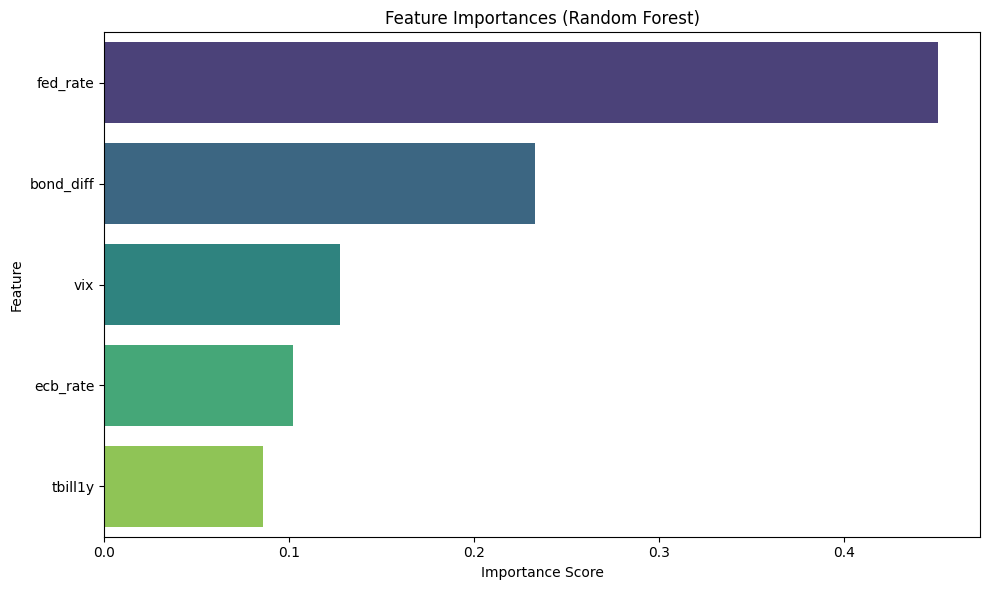

In [14]:

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,       # Ağaç sayısı
    max_depth=5,           # Maksimum derinlik (overfitting’i azaltmak için)
    min_samples_split=2,    # Bir düğümün bölünebilmesi için gereken minimum örnek sayısı
    min_samples_leaf=1,     # Yaprak düğümünde olması gereken minimum örnek sayısı
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R^2:", r2_score(y_test, y_pred_rf))

importances = rf.feature_importances_

feature_names = features
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df, palette="viridis")
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


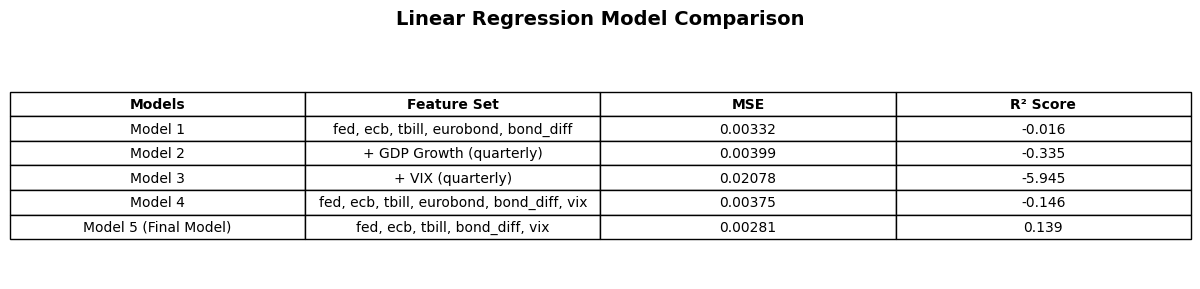

In [13]:
import matplotlib.pyplot as plt

models = [
    ["Model 1", "fed, ecb, tbill, eurobond, bond_diff", 0.00332, -0.016],
    ["Model 2", "+ GDP Growth (quarterly)", 0.00399, -0.335],
    ["Model 3", "+ VIX (quarterly)", 0.02078, -5.945],
    ["Model 4", "fed, ecb, tbill, eurobond, bond_diff, vix", 0.00375, -0.146],
    ["Model 5 (Final Model)", "fed, ecb, tbill, bond_diff, vix", 0.00281, 0.139]
]

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
column_labels = ["Models", "Feature Set", "MSE", "R² Score"]
table_data = models

table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.title("Linear Regression Model Comparison", fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()


### RNN MODELS

In [1314]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.model_selection import train_test_split

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


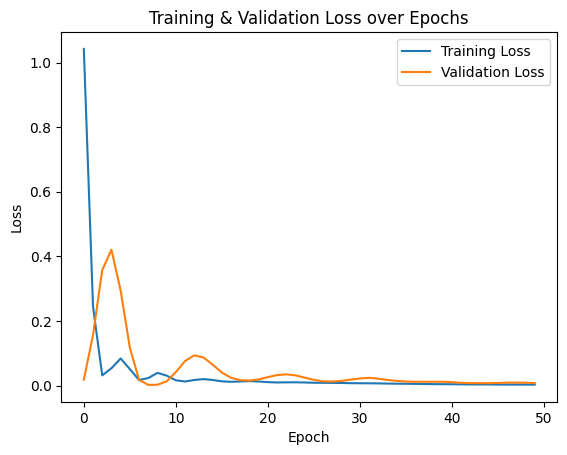

In [1328]:
# RNN Model
sequence_length = 30    # use previous 30 days
scaler = MinMaxScaler()

input_features = data.drop(columns=["eurusd"])
target = data["eurusd"]

# Scale
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(input_features)
scaled_y = scaler_y.fit_transform(target.values.reshape(-1, 1))

X_seq, y_seq = [], []
for i in range(len(scaled_X) - sequence_length):
    X_seq.append(scaled_X[i:i+sequence_length])
    y_seq.append(scaled_y[i + sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq).flatten()

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(sequence_length, X_seq.shape[2])),
    Dense(1)
])

# Train
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, validation_split=0.1, verbose=0)

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Training & Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
RNN MSE: 0.001418
RNN R^2: 0.902661


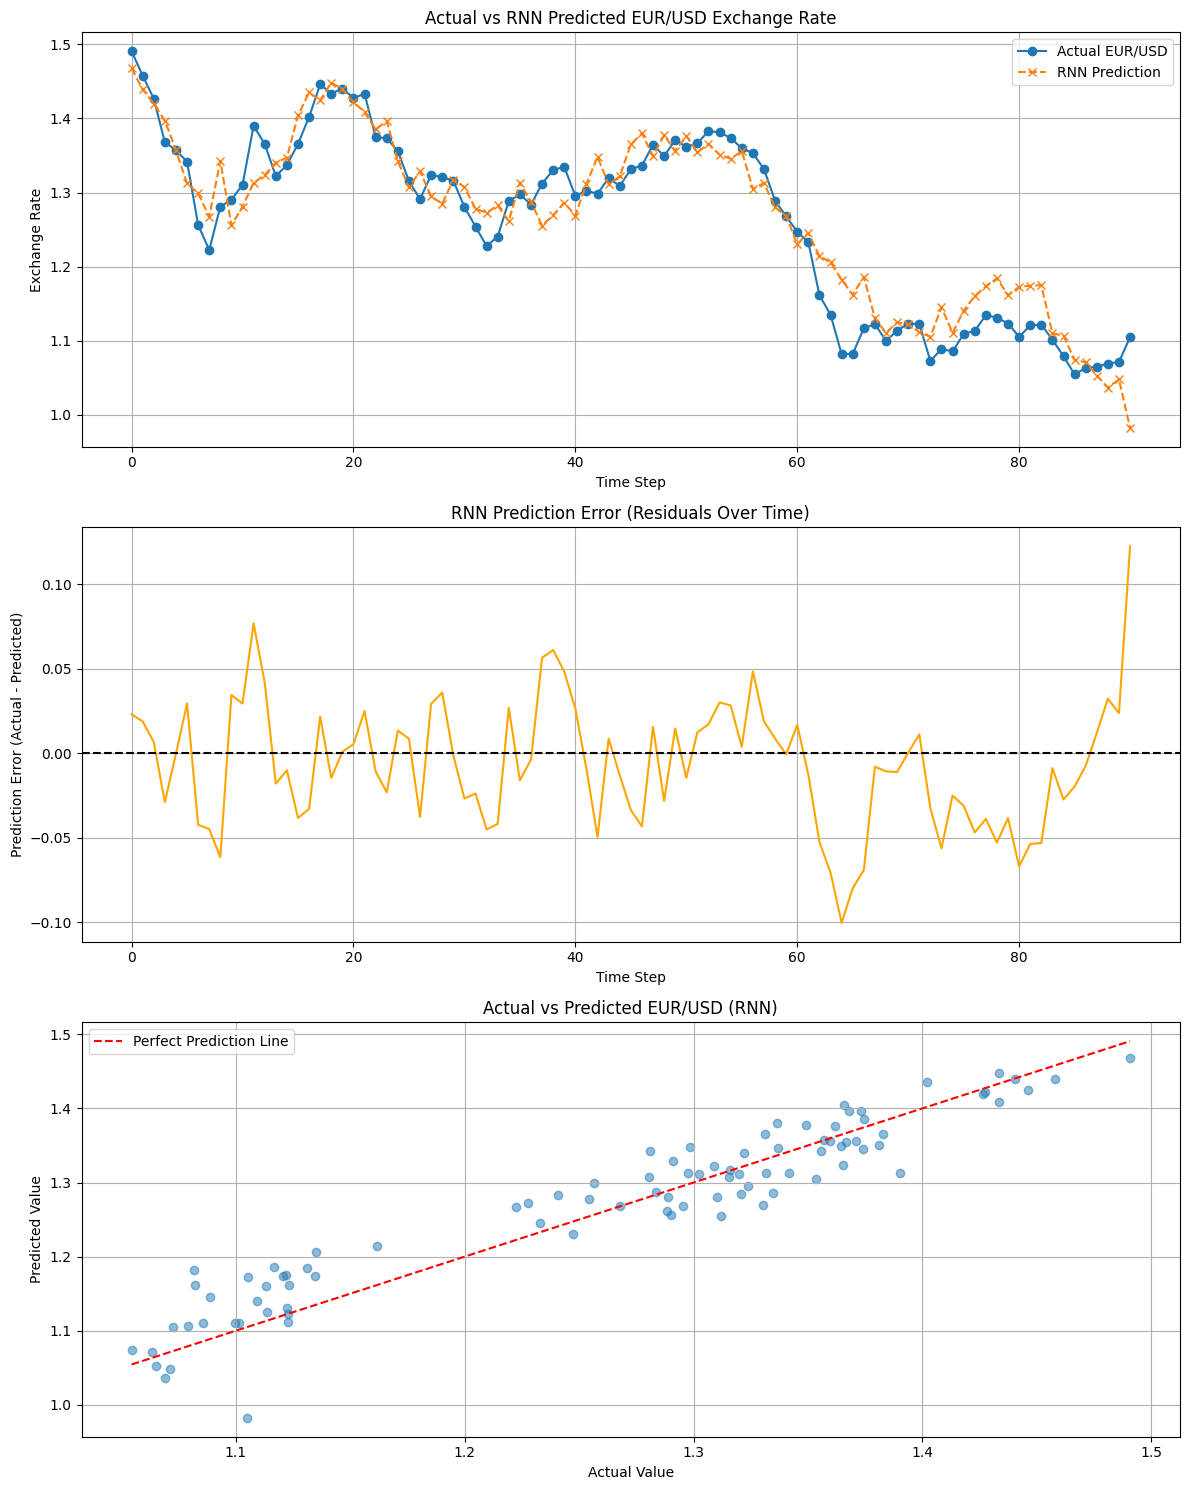

In [1329]:
X_all_seq = np.array([
    scaled_X[i:i+sequence_length]
    for i in range(len(scaled_X) - sequence_length)
])

rnn_preds_scaled = model.predict(X_all_seq).flatten()
rnn_preds_unscaled = scaler_y.inverse_transform(rnn_preds_scaled.reshape(-1, 1)).flatten()
y_seq_unscaled = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()

# Evaluate Performance
mse = mean_squared_error(y_seq_unscaled, rnn_preds_unscaled)
r2 = r2_score(y_seq_unscaled, rnn_preds_unscaled)

print(f"RNN MSE: {mse:.6f}")
print(f"RNN R^2: {r2:.6f}")


# Compute residuals for RNN
residuals = y_seq_unscaled - rnn_preds_unscaled

# Create a single figure with 3 vertically stacked subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

# 1. Line Plot: Actual vs RNN Predictions
axs[0].plot(y_seq_unscaled, label="Actual EUR/USD", marker='o')
axs[0].plot(rnn_preds_unscaled, label="RNN Prediction", marker='x', linestyle='--')
axs[0].set_title("Actual vs RNN Predicted EUR/USD Exchange Rate")
axs[0].set_xlabel("Time Step")
axs[0].set_ylabel("Exchange Rate")
axs[0].legend()
axs[0].grid(True)

# 2. Residual Plot: RNN Errors Over Time
axs[1].plot(residuals, color="orange")
axs[1].axhline(0, color="black", linestyle="--")
axs[1].set_title("RNN Prediction Error (Residuals Over Time)")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("Prediction Error (Actual - Predicted)")
axs[1].grid(True)

# 3. Scatter Plot: Actual vs RNN Predicted
axs[2].scatter(y_seq_unscaled, rnn_preds_unscaled, alpha=0.5)
axs[2].plot([min(y_seq_unscaled), max(y_seq_unscaled)],
            [min(y_seq_unscaled), max(y_seq_unscaled)],
            color="red", linestyle="--", label="Perfect Prediction Line")
axs[2].set_title("Actual vs Predicted EUR/USD (RNN)")
axs[2].set_xlabel("Actual Value")
axs[2].set_ylabel("Predicted Value")
axs[2].legend()
axs[2].grid(True)

# Final layout adjustment
plt.tight_layout()
plt.show()


In [1330]:
rnn_test_preds_scaled = model.predict(X_test_seq).flatten()
rnn_test_preds_unscaled = scaler_y.inverse_transform(rnn_test_preds_scaled.reshape(-1, 1)).flatten()
y_test_seq_unscaled = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Evaluate Performance
mse = mean_squared_error(y_test_seq_unscaled, rnn_test_preds_unscaled)
r2 = r2_score(y_test_seq_unscaled, rnn_test_preds_unscaled)

print(f"RNN MSE (test): {mse:.6f}")
print(f"RNN R^2  (test): {r2:.6f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
RNN MSE (test): 0.002216
RNN R^2  (test): -2.670376


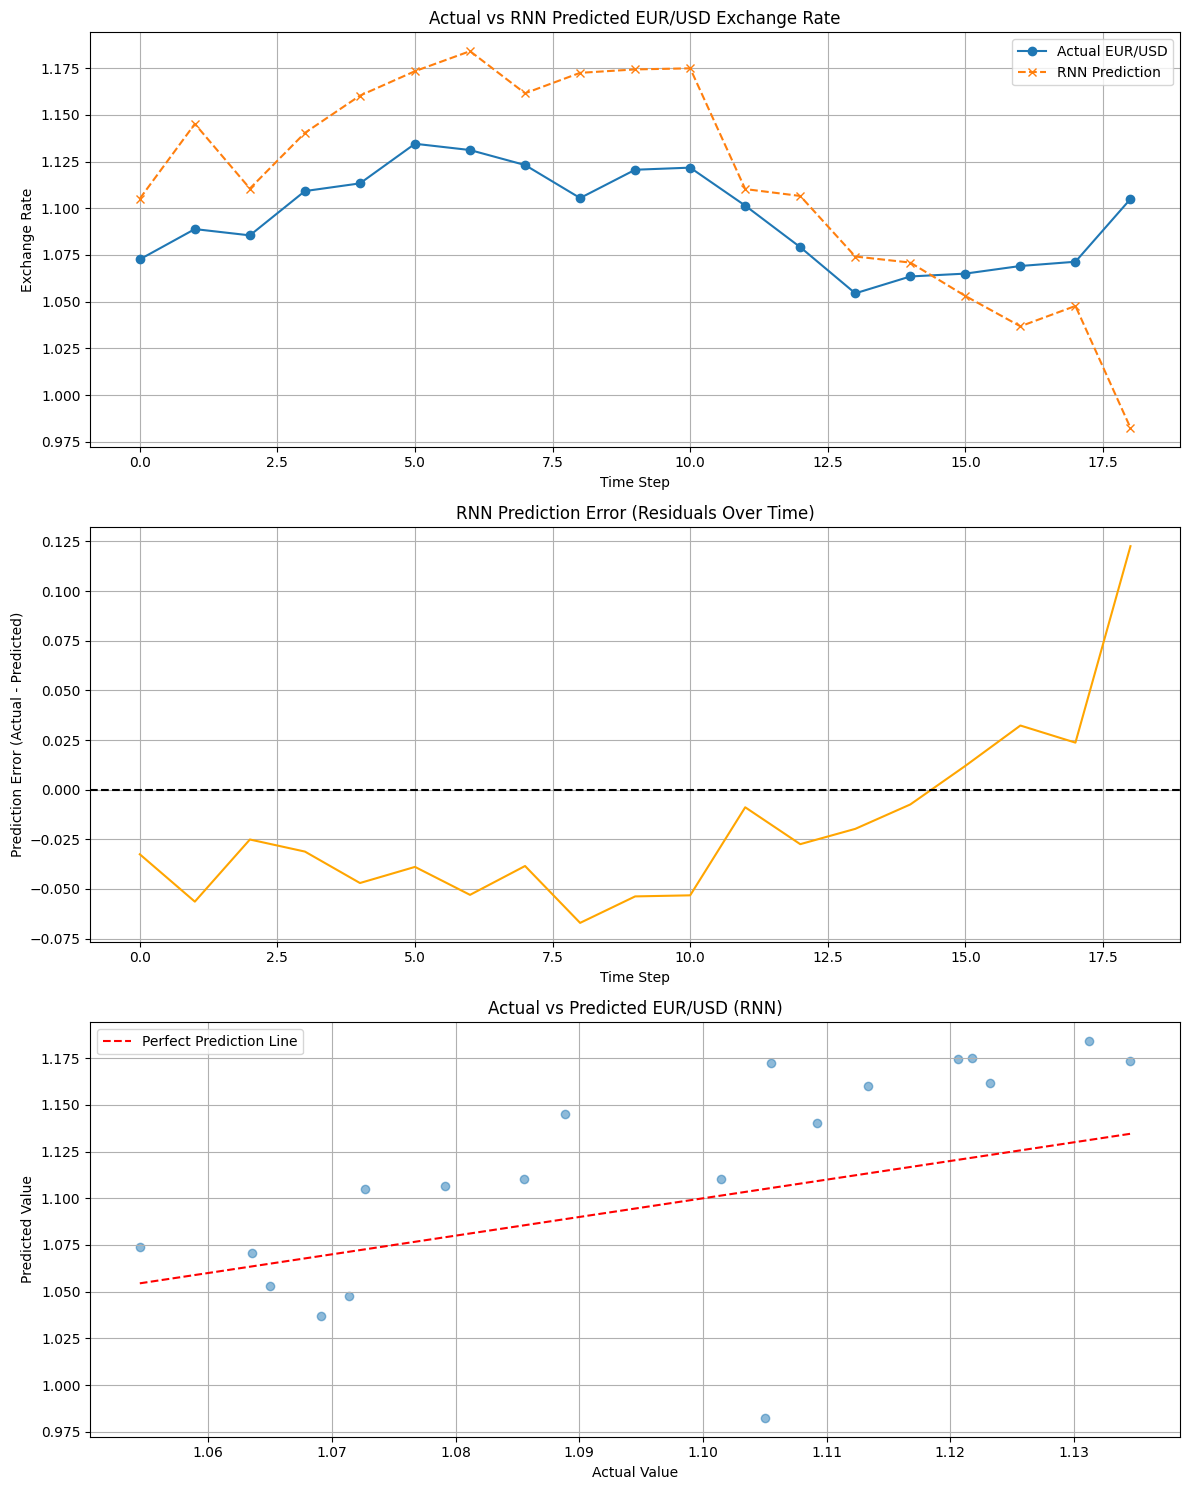

In [1332]:
# Compute residuals for RNN
residuals = y_test_seq_unscaled - rnn_test_preds_unscaled

# Create a single figure with 3 vertically stacked subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

# 1. Line Plot: Actual vs RNN Predictions
axs[0].plot(y_test_seq_unscaled, label="Actual EUR/USD", marker='o')
axs[0].plot(rnn_test_preds_unscaled, label="RNN Prediction", marker='x', linestyle='--')
axs[0].set_title("Actual vs RNN Predicted EUR/USD Exchange Rate")
axs[0].set_xlabel("Time Step")
axs[0].set_ylabel("Exchange Rate")
axs[0].legend()
axs[0].grid(True)

# 2. Residual Plot: RNN Errors Over Time
axs[1].plot(residuals, color="orange")
axs[1].axhline(0, color="black", linestyle="--")
axs[1].set_title("RNN Prediction Error (Residuals Over Time)")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("Prediction Error (Actual - Predicted)")
axs[1].grid(True)

# 3. Scatter Plot: Actual vs RNN Predicted
axs[2].scatter(y_test_seq_unscaled, rnn_test_preds_unscaled, alpha=0.5)
axs[2].plot([min(y_test_seq_unscaled), max(y_test_seq_unscaled)],
            [min(y_test_seq_unscaled), max(y_test_seq_unscaled)],
            color="red", linestyle="--", label="Perfect Prediction Line")
axs[2].set_title("Actual vs Predicted EUR/USD (RNN)")
axs[2].set_xlabel("Actual Value")
axs[2].set_ylabel("Predicted Value")
axs[2].legend()
axs[2].grid(True)

# Final layout adjustment
plt.tight_layout()
plt.show()


The significant drop in the perfomance of the test data indicate overfitting in the training process. Since one of the reasons behind the unability to generalize the patterns is the limited amount of data, daily frequency is gathered to train the model. Also, to prevent overfitting dropout and early stopping methods will be utilized.

In [1322]:
eurusd = web.DataReader("DEXUSEU", "fred", start, end)
fed_rate = web.DataReader("FEDFUNDS", "fred", start, end)
ecb_rate = web.DataReader("ECBMRRFR", "fred", start, end)
tbill1y = web.DataReader("GS1", "fred", start, end)
euro_govbond = web.DataReader("INTGSBEZM193N", "fred", start, end)
us_cpi = web.DataReader("CPILFESL", "fred", start, end)
euro_cpi = web.DataReader("EA19CPALTT01GYM", "fred", start, end)
vix = web.DataReader("VIXCLS", "fred", start, end)  # ← CBOE Volatility Index (daily)

daily_index = eurusd.index
df = pd.DataFrame(index=daily_index)

df["eurusd"] = eurusd["DEXUSEU"]
df["fed_rate"] = fed_rate.reindex(daily_index).ffill()
df["ecb_rate"] = ecb_rate.reindex(daily_index).ffill()
df["tbill1y"] = tbill1y.reindex(daily_index).ffill()
df["euro_govbond"] = euro_govbond.reindex(daily_index).ffill()
df["us_cpi"] = us_cpi.reindex(daily_index).ffill()
df["euro_cpi"] = euro_cpi.reindex(daily_index).ffill()
df["vix"] = vix.reindex(daily_index).ffill()
df["vix_lag1"] = df["vix"].shift(1)
df["bond_diff"] = df["tbill1y"] - df["euro_govbond"]

df.dropna(inplace=True)

print(df.shape)
print(df.head())

(6605, 10)
            eurusd  fed_rate  ecb_rate  tbill1y  euro_govbond  us_cpi  \
DATE                                                                    
1999-02-01  1.1303      4.76       3.0      4.7        3.9742   175.6   
1999-02-02  1.1328      4.76       3.0      4.7        3.9742   175.6   
1999-02-03  1.1339      4.76       3.0      4.7        3.9742   175.6   
1999-02-04  1.1306      4.76       3.0      4.7        3.9742   175.6   
1999-02-05  1.1283      4.76       3.0      4.7        3.9742   175.6   

            euro_cpi    vix  vix_lag1  bond_diff  
DATE                                              
1999-02-01  0.835616  27.67     26.25     0.7258  
1999-02-02  0.835616  28.16     27.67     0.7258  
1999-02-03  0.835616  27.88     28.16     0.7258  
1999-02-04  0.835616  29.48     27.88     0.7258  
1999-02-05  0.835616  29.67     29.48     0.7258  


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


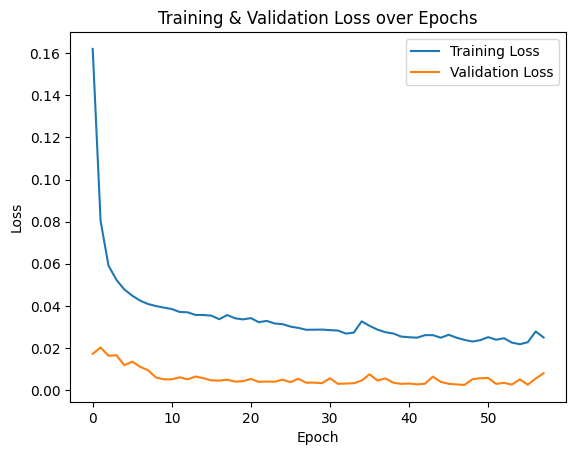

In [1341]:
# RNN Model with daily data

from keras.layers import Dropout
from keras.callbacks import EarlyStopping

sequence_length = 30    # use previous 30 days
scaler = MinMaxScaler()

input_features = df.drop(columns=["eurusd"])
target = df["eurusd"]

# Scale
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(input_features)
scaled_y = scaler_y.fit_transform(target.values.reshape(-1, 1))

X_seq, y_seq = [], []
for i in range(len(scaled_X) - sequence_length):
    X_seq.append(scaled_X[i:i+sequence_length])
    y_seq.append(scaled_y[i + sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq).flatten()

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

early_stop = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=10,             # Stop if no improvement for 10 epochs
    restore_best_weights=True # Roll back to best model weights
)

model = Sequential([
    SimpleRNN(64,
              activation='tanh',
              input_shape=(sequence_length, X_seq.shape[2]),
              dropout=0.15,                  # dropout on input connections
              recurrent_dropout=0.15),       # dropout on recurrent state (hidden-to-hidden)
              Dropout(0.15),                  # extra dropout after RNN layer
              Dense(1)
])

# Train
model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=500,
    batch_size=32,
    validation_split=0.1,
    verbose=0,
    callbacks=[early_stop]
)

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Training & Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RNN MSE: 0.006091
RNN R^2: 0.748772


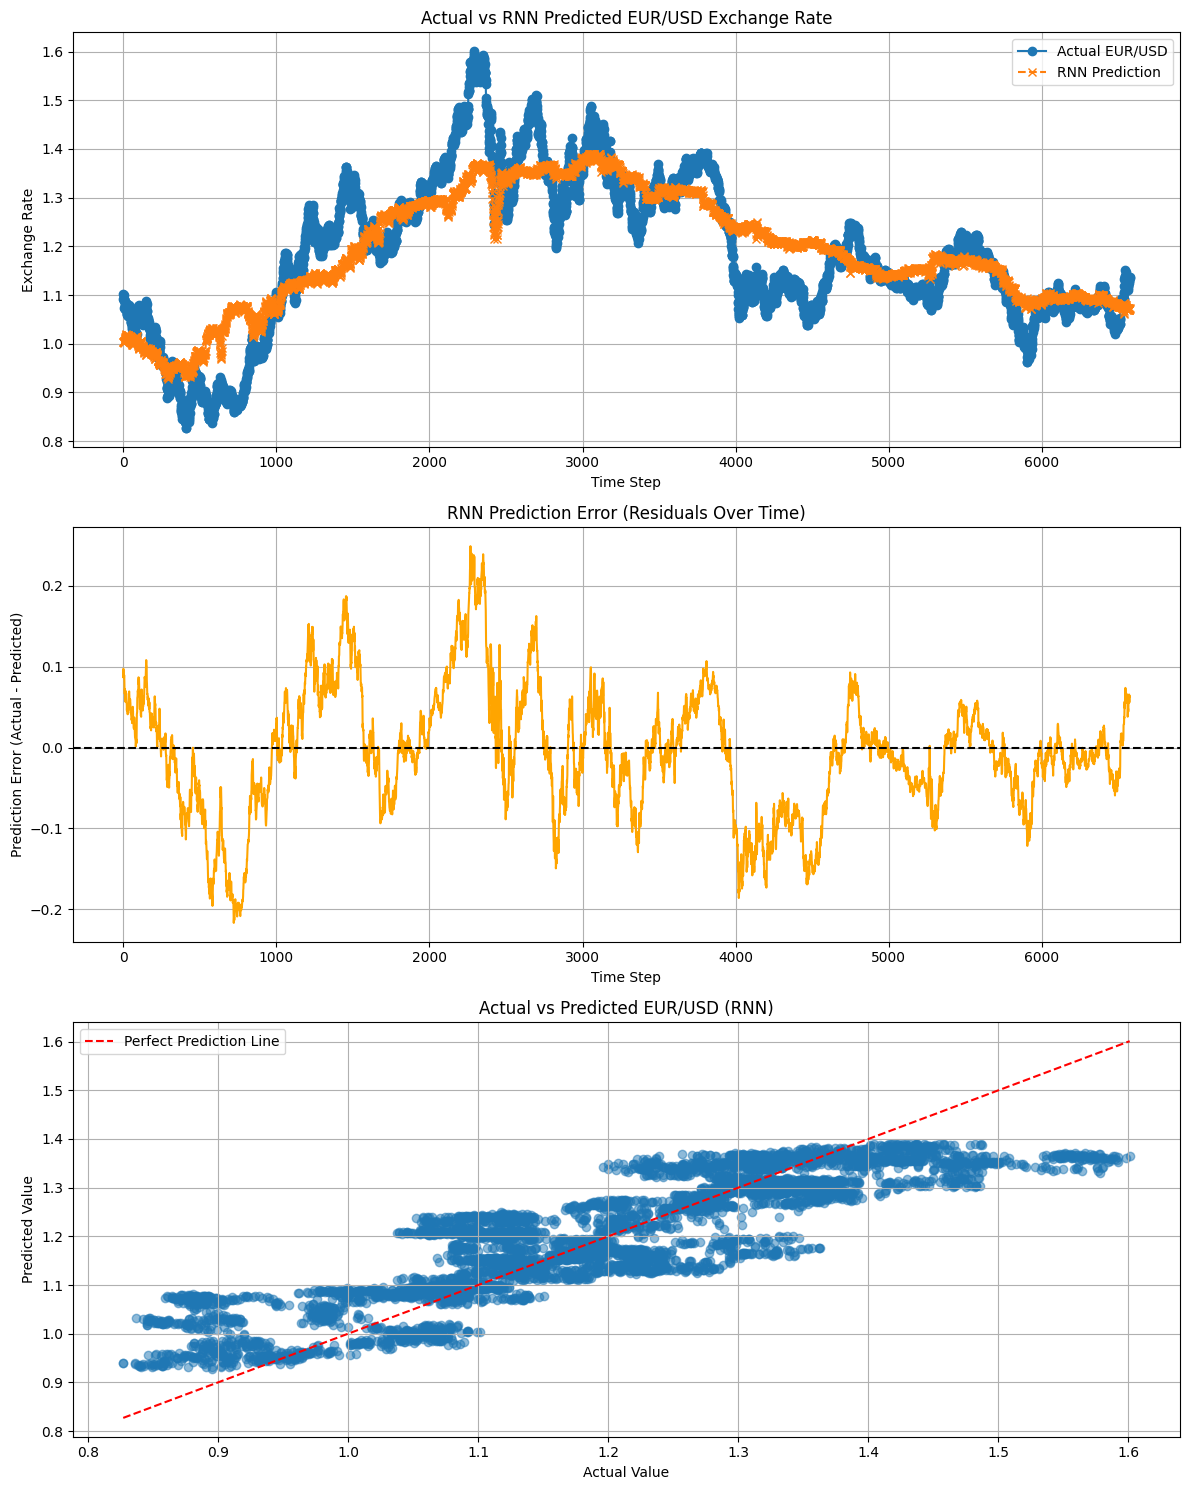

In [1342]:
X_all_seq = np.array([
    scaled_X[i:i+sequence_length]
    for i in range(len(scaled_X) - sequence_length)
])

rnn_preds_scaled = model.predict(X_all_seq).flatten()
rnn_preds_unscaled = scaler_y.inverse_transform(rnn_preds_scaled.reshape(-1, 1)).flatten()
y_seq_unscaled = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()

# Evaluate Performance
mse = mean_squared_error(y_seq_unscaled, rnn_preds_unscaled)
r2 = r2_score(y_seq_unscaled, rnn_preds_unscaled)

print(f"RNN MSE: {mse:.6f}")
print(f"RNN R^2: {r2:.6f}")


# Compute residuals for RNN
residuals = y_seq_unscaled - rnn_preds_unscaled

# Create a single figure with 3 vertically stacked subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

# 1. Line Plot: Actual vs RNN Predictions
axs[0].plot(y_seq_unscaled, label="Actual EUR/USD", marker='o')
axs[0].plot(rnn_preds_unscaled, label="RNN Prediction", marker='x', linestyle='--')
axs[0].set_title("Actual vs RNN Predicted EUR/USD Exchange Rate")
axs[0].set_xlabel("Time Step")
axs[0].set_ylabel("Exchange Rate")
axs[0].legend()
axs[0].grid(True)

# 2. Residual Plot: RNN Errors Over Time
axs[1].plot(residuals, color="orange")
axs[1].axhline(0, color="black", linestyle="--")
axs[1].set_title("RNN Prediction Error (Residuals Over Time)")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("Prediction Error (Actual - Predicted)")
axs[1].grid(True)

# 3. Scatter Plot: Actual vs RNN Predicted
axs[2].scatter(y_seq_unscaled, rnn_preds_unscaled, alpha=0.5)
axs[2].plot([min(y_seq_unscaled), max(y_seq_unscaled)],
            [min(y_seq_unscaled), max(y_seq_unscaled)],
            color="red", linestyle="--", label="Perfect Prediction Line")
axs[2].set_title("Actual vs Predicted EUR/USD (RNN)")
axs[2].set_xlabel("Actual Value")
axs[2].set_ylabel("Predicted Value")
axs[2].legend()
axs[2].grid(True)

# Final layout adjustment
plt.tight_layout()
plt.show()


In [1343]:
rnn_test_preds_scaled = model.predict(X_test_seq).flatten()
rnn_test_preds_unscaled = scaler_y.inverse_transform(rnn_test_preds_scaled.reshape(-1, 1)).flatten()
y_test_seq_unscaled = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Evaluate Performance
mse = mean_squared_error(y_test_seq_unscaled, rnn_test_preds_unscaled)
r2 = r2_score(y_test_seq_unscaled, rnn_test_preds_unscaled)

print(f"RNN MSE (test): {mse:.6f}")
print(f"RNN R^2  (test): {r2:.6f}")

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
RNN MSE (test): 0.001532
RNN R^2  (test): 0.545605


RNN MSE: 0.001532
RNN R^2: 0.545605


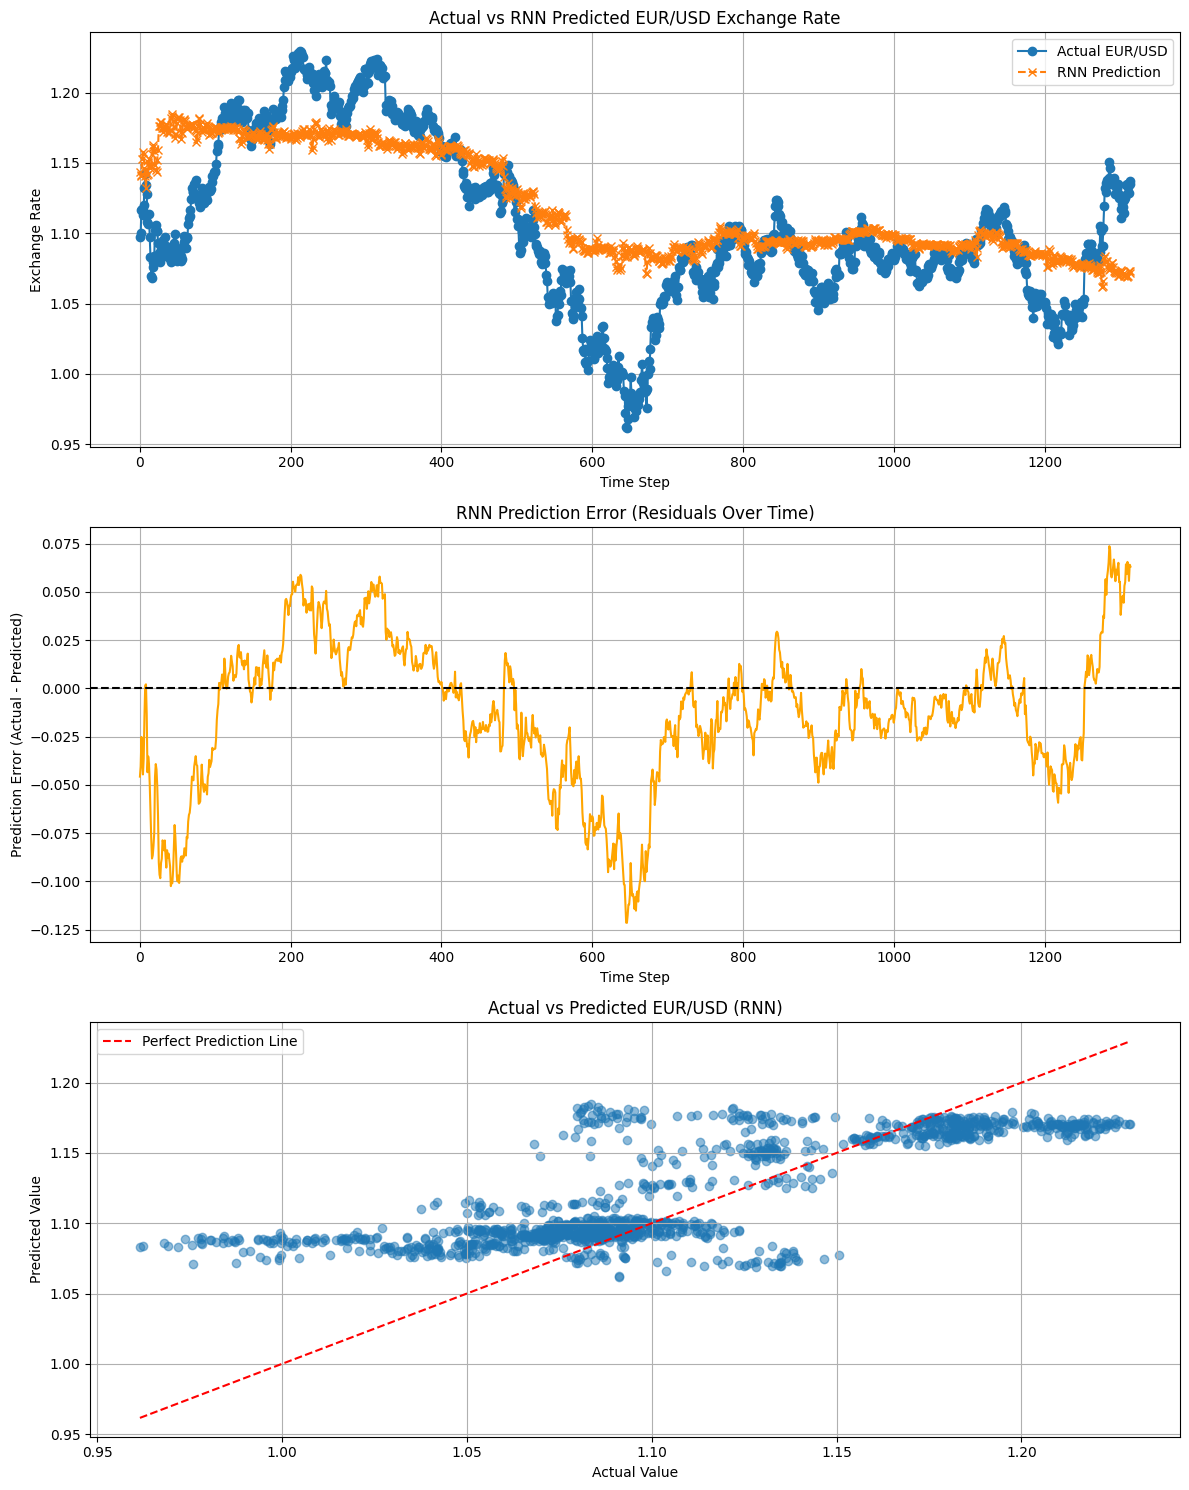

In [1345]:
# Evaluate Performance
mse = mean_squared_error(y_test_seq_unscaled, rnn_test_preds_unscaled)
r2 = r2_score(y_test_seq_unscaled, rnn_test_preds_unscaled)

print(f"RNN MSE: {mse:.6f}")
print(f"RNN R^2: {r2:.6f}")


# Compute residuals for RNN
residuals = y_test_seq_unscaled - rnn_test_preds_unscaled

# Create a single figure with 3 vertically stacked subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

# 1. Line Plot: Actual vs RNN Predictions
axs[0].plot(y_test_seq_unscaled, label="Actual EUR/USD", marker='o')
axs[0].plot(rnn_test_preds_unscaled, label="RNN Prediction", marker='x', linestyle='--')
axs[0].set_title("Actual vs RNN Predicted EUR/USD Exchange Rate")
axs[0].set_xlabel("Time Step")
axs[0].set_ylabel("Exchange Rate")
axs[0].legend()
axs[0].grid(True)

# 2. Residual Plot: RNN Errors Over Time
axs[1].plot(residuals, color="orange")
axs[1].axhline(0, color="black", linestyle="--")
axs[1].set_title("RNN Prediction Error (Residuals Over Time)")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("Prediction Error (Actual - Predicted)")
axs[1].grid(True)

# 3. Scatter Plot: Actual vs RNN Predicted
axs[2].scatter(y_test_seq_unscaled, rnn_test_preds_unscaled, alpha=0.5)
axs[2].plot([min(y_test_seq_unscaled), max(y_test_seq_unscaled)],
            [min(y_test_seq_unscaled), max(y_test_seq_unscaled)],
            color="red", linestyle="--", label="Perfect Prediction Line")
axs[2].set_title("Actual vs Predicted EUR/USD (RNN)")
axs[2].set_xlabel("Actual Value")
axs[2].set_ylabel("Predicted Value")
axs[2].legend()
axs[2].grid(True)

# Final layout adjustment
plt.tight_layout()
plt.show()
